# How many dimensions does each analysis actually see?

`grid_space.ipynb` sweeps within-region clustering ($a$) against across-region clustering
($c$) and scores every cell two ways: pooling neurons, and comparing whole regions with the
Procrustes distance. Neither $z$ says how many dimensions the underlying cloud occupies, and
silhouette itself is dimensionality-dependent, so this notebook adds that missing axis:
the **participation ratio** of each cloud, at every $(a, c)$ cell of the same grid.

$$\mathrm{PR}(\lambda) = \frac{\left(\sum_i \lambda_i\right)^2}{\sum_i \lambda_i^2}$$

for the eigenvalues $\lambda$ of a covariance (or Gram) matrix. PR is 1 for a cloud stretched
along a single axis and equal to the ambient dimension for an isotropic one -- it is the
standard "effective dimensionality" used elsewhere in this repo (the HD ring, the manifold
variance checks in `region_summary_6x3.ipynb`).

Three clouds, matching what each analysis actually operates on:

| PR | the cloud | matches |
|---|---|---|
| **neuron** | the pooled, per-neuron-standardised tuning-shape cloud | `z_pooled`'s input, before its 90%-variance truncation |
| **region** | the $K$ regions in Procrustes shape space (classical MDS Gram matrix) | `z_regions`'s input, before truncation to `EMB_DIM` |
| **manifold** | one region's own population manifold (conditions in neuron-firing-rate space) | the object a *single* Procrustes distance compares |

No null draws are computed here -- PR needs only the field itself, not a clustering test, so
this notebook is far cheaper than `grid_space.ipynb` despite covering the same grid.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

HERE = next(p for p in (Path.cwd(), Path.cwd() / "clustering-simulation",
                        *Path.cwd().parents)
            if (p / "region_space.py").exists())
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE.parent))
sys.path.insert(0, str(HERE.parent / "Posani/code"))
import grid_space as G                                             # noqa: E402
import region_space as R                                           # noqa: E402
import shapemetrics as sm                                          # noqa: E402
import plotting                                                    # noqa: E402

OUT = HERE / "results"
OUT.mkdir(exist_ok=True)
plt.rcParams.update({"svg.fonttype": "none", "text.usetex": False})

N_GRID, SEEDS = 7, (0, 1, 2)
AVALS = np.sort(1 - np.logspace(np.log10(0.05), 0.0, N_GRID))    # as grid_space.ipynb
CVALS = np.linspace(0.0, 1.0, N_GRID)
N_MANIFOLD_REGIONS = 12          # subsample of regions per cell, for the manifold PR


def participation_ratio(eigs):
    """(sum lambda)^2 / sum(lambda^2), the eigenvalues clipped at 0."""
    eigs = np.clip(np.asarray(eigs, float), 0, None)
    return float(eigs.sum() ** 2 / (eigs ** 2).sum())


def neuron_pr(X, rng, n_pool=G.N_POOL):
    """PR of the pooled, per-neuron-standardised cloud -- exactly the input to
    `sm.pipeline_silhouette` (via Posani's `dr`, which is sklearn PCA under the
    hood), read off BEFORE the 90%-variance truncation."""
    idx = rng.choice(len(X), min(n_pool, len(X)), replace=False)
    A = X[idx]
    Xs = (A - A.mean(1, keepdims=True)) / A.std(1, keepdims=True)
    ev = PCA().fit(Xs).explained_variance_
    return participation_ratio(ev)


def region_pr(X, region):
    """PR of the K regions in Procrustes shape space -- the classical-MDS Gram
    matrix `z_regions` embeds, read off before truncation to EMB_DIM."""
    D = sm.distance_matrix(X, region, n_pcs=G.N_PCS, alpha=1)
    n = len(D)
    J = np.eye(n) - np.ones((n, n)) / n
    w = np.linalg.eigvalsh(-0.5 * J @ (D ** 2) @ J)
    return participation_ratio(w)


def manifold_pr(X, region, rng, n_regions=N_MANIFOLD_REGIONS):
    """PR of a single region's population manifold: conditions as points in
    neuron-firing-rate space, which is the object one Procrustes distance
    compares.  Averaged over a subsample of regions, since PR is a property of
    one region and this notebook otherwise reports one number per cell."""
    regions = rng.choice(np.unique(region), min(n_regions, len(np.unique(region))),
                         replace=False)
    prs = [participation_ratio(PCA().fit(X[region == r].T).explained_variance_)
           for r in regions]
    return float(np.mean(prs))

## The grid

Run at `G.N_NEURONS` (150, `grid_space.ipynb`'s published setting) and again at 2000,
matching the neuron count used in the current `region_summary_6x3.ipynb` heatmaps. No null
draws, so both sweeps together are far cheaper than one run of `grid_space.ipynb`.

In [2]:
def sweep(n_neurons, save_id):
    f = OUT / f"dimensionality_grid_n{n_neurons}.npz"
    if f.exists():
        d = np.load(f)
        return d["PRN"], d["PRR"], d["PRM"]
    PRN = np.zeros((N_GRID, N_GRID, len(SEEDS)))
    PRR = np.zeros((N_GRID, N_GRID, len(SEEDS)))
    PRM = np.zeros((N_GRID, N_GRID, len(SEEDS)))
    for i, a in enumerate(AVALS):
        for j, c in enumerate(CVALS):
            for s, seed in enumerate(SEEDS):
                X, region, _ = G.field(a, c, seed=seed, n_neurons=n_neurons)
                rng = np.random.default_rng(700 + seed)
                PRN[i, j, s] = neuron_pr(X, rng)
                PRR[i, j, s] = region_pr(X, region)
                PRM[i, j, s] = manifold_pr(X, region, rng)
        print(f"  [{save_id}] a = {a:.2f} done", flush=True)
    np.savez(f, PRN=PRN, PRR=PRR, PRM=PRM)
    return PRN, PRR, PRM


PRN150, PRR150, PRM150 = sweep(G.N_NEURONS, "N=150")
PRN2000, PRR2000, PRM2000 = sweep(2000, "N=2000")

  [N=150] a = 0.00 done


  [N=150] a = 0.39 done


  [N=150] a = 0.63 done


  [N=150] a = 0.78 done


  [N=150] a = 0.86 done


...

  [N=2000] a = 0.63 done


  [N=2000] a = 0.78 done


  [N=2000] a = 0.86 done


  [N=2000] a = 0.92 done


  [N=2000] a = 0.95 done


## Reading it

For each cloud, the question is the same one the z-score grid asks: does PR vary along $a$,
along $c$, both, or neither.

In [3]:
from scipy import stats

def report(tag, M):
    m = M.mean(2); ny, nx = m.shape
    yi = np.repeat(np.arange(ny), nx); xi = np.tile(np.arange(nx), ny)
    ra = stats.spearmanr(yi, m.ravel()).statistic
    rc = stats.spearmanr(xi, m.ravel()).statistic
    print(f"{tag:>28s}: range {m.min():5.2f} to {m.max():5.2f}   "
          f"rho(a) {ra:+.2f}   rho(c) {rc:+.2f}")

for tag, M in (("neuron PR, N=150", PRN150), ("neuron PR, N=2000", PRN2000),
              ("region PR, N=150", PRR150), ("region PR, N=2000", PRR2000),
              ("manifold PR, N=150", PRM150), ("manifold PR, N=2000", PRM2000)):
    report(tag, M)

            neuron PR, N=150: range  1.43 to  1.53   rho(a) -0.74   rho(c) -0.65
           neuron PR, N=2000: range  1.41 to  1.51   rho(a) -0.79   rho(c) -0.59
            region PR, N=150: range  1.28 to  1.38   rho(a) -0.64   rho(c) -0.64
           region PR, N=2000: range  1.09 to  1.17   rho(a) -0.05   rho(c) -0.98
          manifold PR, N=150: range  1.07 to  1.07   rho(a) +0.99   rho(c) +0.12
         manifold PR, N=2000: range  1.07 to  1.07   rho(a) +0.38   rho(c) +0.10


## The heatmaps

Same layout as `grid_space.ipynb`'s $z$-score grid, so the two are directly comparable panel
for panel. Each map has its own colour scale.

'/Users/joaobarbosa/Dropbox/proton_backup/Neuro/papers/shapemetrics_journalpaper/clustering-simulation/results/dimensionality_grid.pdf'

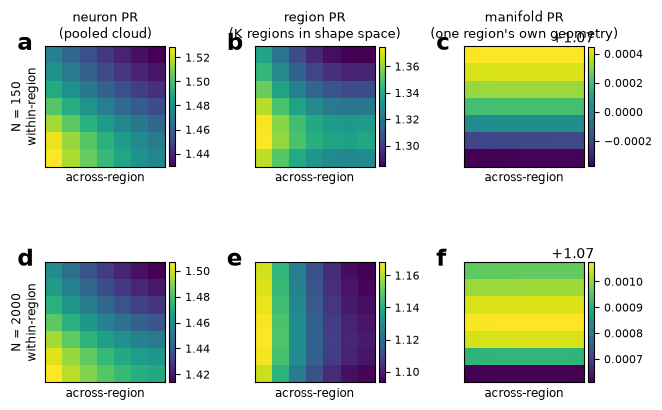

In [4]:
PANEL = 2.24
fig, axes = plt.subplots(2, 3, figsize=(3 * PANEL, 2.1 * PANEL))
ROWS = [("N = 150", PRN150, PRR150, PRM150), ("N = 2000", PRN2000, PRR2000, PRM2000)]
TITLES = ["neuron PR\n(pooled cloud)", "region PR\n(K regions in shape space)",
         "manifold PR\n(one region's own geometry)"]

for row, (tag, PN, PRr, PM) in enumerate(ROWS):
    for col, (M, ttl) in enumerate(zip((PN, PRr, PM), TITLES)):
        ax = axes[row, col]
        im = ax.imshow(M.mean(2), origin="lower", cmap="viridis", aspect="auto")
        ax.set_box_aspect(1); ax.set(xticks=[], yticks=[])
        if row == 0:
            ax.set_title(ttl)
        if col == 0:
            ax.set_ylabel(f"{tag}\nwithin-region")
        ax.set_xlabel("across-region")
        cb = fig.colorbar(im, ax=ax, fraction=.046, pad=.03)
        cb.ax.tick_params(labelsize=plotting.FS_TICK - 1)

for ax, L in zip(axes.ravel(), "abcdef"):
    plotting.panel_letter(ax, L, dx=-20)
plotting.typeset(fig)
fig.tight_layout(w_pad=1.2, h_pad=1.0)
plotting.save(fig, "dimensionality_grid", folder=str(OUT))